# Neural SARSA on a Tiny CliffWorld

**Goal:** implement the SARSA update with a small hidden-layer neural network.

We use a custom $3 \times 4$ cliff environment:

```text
.  .  .  .
.  .  .  .
S  C  C  G
```

- `S`: start
- `C`: cliff
- `G`: goal

The state is represented by normalized coordinates:

$$
s = (x,y)
$$

The neural network approximates action values:

$$
Q_\theta(s,a)
$$

The SARSA target is

$$
y_t =
\begin{cases}
r_t, & \text{if the episode ended},\\
r_t + \gamma Q_\theta(s_{t+1}, a_{t+1}), & \text{otherwise}.
\end{cases}
$$

The only important programming task is to fill in the SARSA update.


## Setup

This notebook does **not** need Gymnasium.  
The environment is implemented directly below so that the exercise stays small and deterministic enough for a live session.

In [12]:
# If needed:
# !pip install torch matplotlib tqdm

import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

# Makes the notebook faster and more predictable on small CPU workloads.
torch.set_num_threads(1)


In [13]:
SEED = 7

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Tiny CliffWorld environment

Actions:

| Action id | Meaning |
|---:|---|
| `0` | up |
| `1` | right |
| `2` | down |
| `3` | left |

Rewards:

- normal step: $-0.1$
- cliff: $-10$
- goal: $+10$

The cliff and the goal are terminal.

In [14]:
class TinyCliffWorld:
    def __init__(self):
        self.height = 3
        self.width = 4

        self.start = (2, 0)
        self.cliff = {(2, 1), (2, 2)}
        self.goal = (2, 3)

        self.n_actions = 4
        self.state = None

        self.valid_start_states = [
            (row, col)
            for row in range(self.height)
            for col in range(self.width)
            if (row, col) not in self.cliff and (row, col) != self.goal
        ]

    def reset(self, random_start=False, random_start_probability=0.8):
        # During training, random starts improve state-space coverage.
        # During evaluation, use random_start=False to always start from S.
        if random_start and random.random() < random_start_probability:
            self.state = random.choice(self.valid_start_states)
        else:
            self.state = self.start

        return self.state

    def step(self, action):
        row, col = self.state

        if action == 0:      # up
            row -= 1
        elif action == 1:    # right
            col += 1
        elif action == 2:    # down
            row += 1
        elif action == 3:    # left
            col -= 1
        else:
            raise ValueError(f"Unknown action: {action}")

        # Stay inside the grid.
        row = min(max(row, 0), self.height - 1)
        col = min(max(col, 0), self.width - 1)

        next_state = (row, col)

        if next_state in self.cliff:
            reward = -10.0
            done = True
        elif next_state == self.goal:
            reward = 10.0
            done = True
        else:
            reward = -0.1
            done = False

        self.state = next_state
        return next_state, reward, done, {}

    def print_grid(self, agent_state=None):
        for row in range(self.height):
            cells = []
            for col in range(self.width):
                state = (row, col)

                if agent_state == state:
                    cells.append("A")
                elif state == self.start:
                    cells.append("S")
                elif state in self.cliff:
                    cells.append("C")
                elif state == self.goal:
                    cells.append("G")
                else:
                    cells.append(".")

            print(" ".join(f"{cell:>2}" for cell in cells))


env = TinyCliffWorld()
env.print_grid()


 .  .  .  .
 .  .  .  .
 S  C  C  G


## State representation: normalized $(x,y)$ coordinates

The environment internally uses grid coordinates `(row, col)`.  
The neural network receives normalized coordinates:

$$
x = \frac{\text{col}}{\text{width}-1},
\qquad
y = \frac{\text{row}}{\text{height}-1}.
$$

So the input dimension is only `2`.

In [15]:
def state_features(state):
    row, col = state

    x = col / (env.width - 1)
    y = row / (env.height - 1)

    return torch.tensor([x, y], dtype=torch.float32)


print("Start state:", env.start)
print("Start features:", state_features(env.start))
print("Goal state:", env.goal)
print("Goal features:", state_features(env.goal))

Start state: (2, 0)
Start features: tensor([0., 1.])
Goal state: (2, 3)
Goal features: tensor([1., 1.])


## Hidden-layer neural Q-function

The network maps coordinates to one Q-value per action:

$$
(x,y) \mapsto
\begin{bmatrix}
Q_\theta(s,\text{up})\\
Q_\theta(s,\text{right})\\
Q_\theta(s,\text{down})\\
Q_\theta(s,\text{left})
\end{bmatrix}.
$$

Architecture:

```text
2 inputs -> hidden layer with 16 units -> 4 action values
```

In [16]:
class TinyQNetwork(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 4),
        )

    def forward(self, features):
        return self.net(features)


@torch.no_grad()
def greedy_action(q_net, state):
    q_values = q_net(state_features(state))
    return int(torch.argmax(q_values).item())


def epsilon_greedy_action(q_net, state, epsilon):
    if random.random() < epsilon:
        return random.randrange(env.n_actions)

    return greedy_action(q_net, state)

## Student task: implement the SARSA update

Fill in the four TODOs.

The update should move $Q_\theta(s_t,a_t)$ toward the SARSA target

$$
r_t + \gamma Q_\theta(s_{t+1}, a_{t+1}).
$$

For terminal transitions, there is no future value, so the target is just

$$
r_t.
$$

In [17]:
def sarsa_update(q_net, optimizer, state, action, reward, next_state, next_action, done, gamma):
    q_values = q_net(state_features(state))

    # Q_theta(s_t, a_t)
    q_sa = q_values[action]

    with torch.no_grad():
        next_q_values = q_net(state_features(next_state))

        # Q_theta(s_{t+1}, a_{t+1})
        next_q_sa = next_q_values[next_action]

        # SARSA target
        td_target = torch.tensor(float(reward), dtype=torch.float32)
        if not done:
            td_target = td_target + gamma * next_q_sa

    # Robust TD-error loss
    loss = F.smooth_l1_loss(q_sa, td_target)

    optimizer.zero_grad()
    loss.backward()

    # Stabilizes neural TD learning.
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=1.0)

    optimizer.step()

    return float(loss.item())

## Training loop

This is on-policy SARSA:

1. choose $a_t$ using the current $\epsilon$-greedy policy,
2. execute $a_t$,
3. choose $a_{t+1}$ using the same current policy,
4. update $Q_\theta(s_t,a_t)$ toward $r_t + \gamma Q_\theta(s_{t+1}, a_{t+1})$.

We use random starts during training to cover the tiny state space faster.  
Evaluation still starts from `S`.

In [18]:
def train_sarsa(
    num_episodes=1500,
    max_steps_per_episode=60,
    gamma=0.95,
    epsilon_start=0.9,
    epsilon_end=0.1,
    lr=0.01,
):
    q_net = TinyQNetwork(hidden_size=16)
    optimizer = torch.optim.Adam(q_net.parameters(), lr=lr)

    episode_returns = []
    losses = []

    for episode in tqdm(range(num_episodes), desc="Training SARSA"):
        # Linear epsilon decay.
        fraction = episode / max(1, num_episodes - 1)
        epsilon = epsilon_start + fraction * (epsilon_end - epsilon_start)

        state = env.reset(random_start=True, random_start_probability=0.8)
        action = epsilon_greedy_action(q_net, state, epsilon)

        total_reward = 0.0

        for step in range(max_steps_per_episode):
            next_state, reward, done, info = env.step(action)

            if done:
                next_action = 0  # arbitrary; ignored by the target when done=True
            else:
                next_action = epsilon_greedy_action(q_net, next_state, epsilon)

            loss = sarsa_update(
                q_net=q_net,
                optimizer=optimizer,
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                next_action=next_action,
                done=done,
                gamma=gamma,
            )

            losses.append(loss)
            total_reward += reward

            if done:
                break

            state = next_state
            action = next_action

        episode_returns.append(total_reward)

    return q_net, episode_returns, losses


## Run training

This should finish in a few seconds on CPU.

In [19]:
q_net, episode_returns, losses = train_sarsa()

print("First 10 returns:", episode_returns[:10])
print("Last 10 returns:", episode_returns[-10:])
print("Mean of last 10 returns:", np.mean(episode_returns[-10:]))

Training SARSA:   0%|          | 0/1500 [00:00<?, ?it/s]

First 10 returns: [-12.5, 6.699999999999998, -11.9, 9.3, -11.0, -10.0, -15.799999999999995, -10.7, 9.1, -11.1]
Last 10 returns: [9.9, 9.6, 9.9, 9.8, 9.6, 10.0, 9.5, 9.8, 9.6, 9.7]
Mean of last 10 returns: 9.74


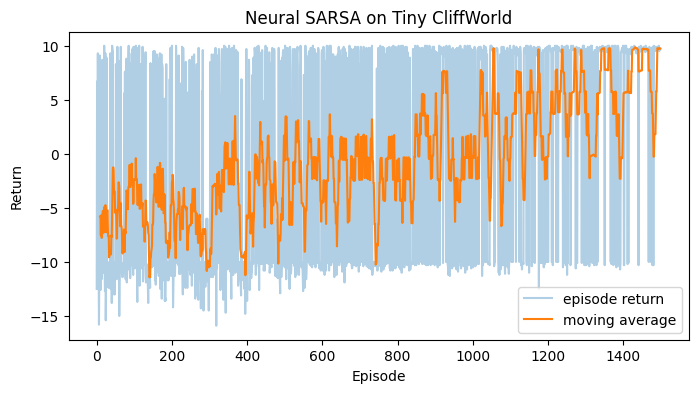

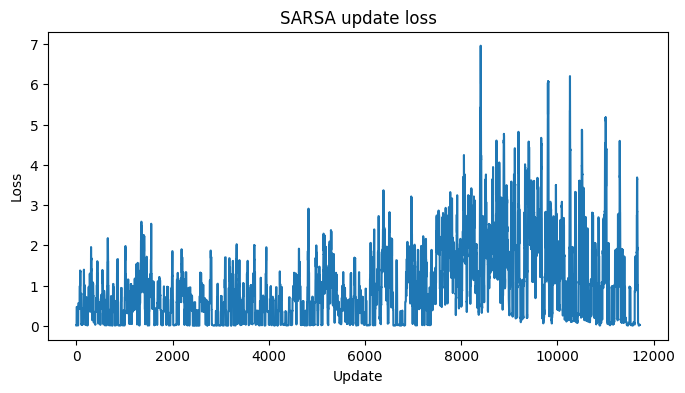

In [20]:
def moving_average(values, window=10):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values

    return np.convolve(values, np.ones(window) / window, mode="valid")


plt.figure(figsize=(8, 4))
plt.plot(episode_returns, alpha=0.35, label="episode return")

ma_returns = moving_average(episode_returns, 10)
plt.plot(
    range(9, 9 + len(ma_returns)),
    ma_returns,
    label="moving average",
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Neural SARSA on Tiny CliffWorld")
plt.legend()
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(moving_average(losses, 20))
plt.xlabel("Update")
plt.ylabel("Loss")
plt.title("SARSA update loss")
plt.show()

## Inspect the greedy policy

Action symbols:

- `↑`: up
- `→`: right
- `↓`: down
- `←`: left

The optimal behavior from the start is approximately:

```text
up, right, right, right, down
```

This crosses the middle row and avoids the cliff cells on the bottom row.


In [21]:
ACTION_SYMBOLS = {
    0: "↑",
    1: "→",
    2: "↓",
    3: "←",
}


def print_greedy_policy(q_net):
    for row in range(env.height):
        cells = []

        for col in range(env.width):
            state = (row, col)

            if state == env.start:
                action = greedy_action(q_net, state)
                cells.append("S" + ACTION_SYMBOLS[action])
            elif state in env.cliff:
                cells.append("C")
            elif state == env.goal:
                cells.append("G")
            else:
                action = greedy_action(q_net, state)
                cells.append(ACTION_SYMBOLS[action])

        print(" ".join(f"{cell:>2}" for cell in cells))


print_greedy_policy(q_net)

 →  →  →  ↓
 →  →  →  ↓
S↑  C  C  G


In [22]:
def evaluate_greedy(q_net, max_steps_per_episode=20):
    state = env.reset(random_start=False)
    path = [state]
    total_reward = 0.0

    for step in range(max_steps_per_episode):
        action = greedy_action(q_net, state)
        next_state, reward, done, info = env.step(action)

        total_reward += reward
        path.append(next_state)

        if done:
            break

        state = next_state

    return total_reward, path


greedy_return, greedy_path = evaluate_greedy(q_net)

print("Greedy return:", greedy_return)
print("Greedy path:", greedy_path)

print("\nPath visualization:")
for state in greedy_path:
    print()
    env.print_grid(agent_state=state)

Greedy return: 9.6
Greedy path: [(2, 0), (1, 0), (1, 1), (1, 2), (1, 3), (2, 3)]

Path visualization:

 .  .  .  .
 .  .  .  .
 A  C  C  G

 .  .  .  .
 A  .  .  .
 S  C  C  G

 .  .  .  .
 .  A  .  .
 S  C  C  G

 .  .  .  .
 .  .  A  .
 S  C  C  G

 .  .  .  .
 .  .  .  A
 S  C  C  G

 .  .  .  .
 .  .  .  .
 S  C  C  A
